# Telecom Churn — Predict, Prioritize, and Act

**Company A retention analytics.** This notebook is the reproducible record behind
the slide deck. It runs top-to-bottom from the raw CSVs in `data/telecom/` and
regenerates every number (`outputs/results/results.json`) and every chart
(`outputs/figures/*.png`).

It deliberately calls the **same tested functions in `src/`** that produced the
deck, so the notebook and the presentation can never disagree.

### What this analysis fixes versus a naive first pass
1. **No protected attributes.** Race/ethnicity, dwelling, marital status, children,
   and other demographic proxies are dropped *before* modeling (legal + ethical).
2. **Honest target & base rate.** The modeling sample is ~50/50 oversampled; we
   train on it but **re-weight calibrated probabilities back to the true ~2%
   churn rate** so the business case is realistic.
3. **Calibrated probabilities**, not raw scores — so "P(churn)=0.3" means it.
4. **Decision threshold set on a profit curve**, not an arbitrary 0.5.
5. **SHAP** for honest, directional drivers (no hand-waving feature importance).
6. **Uplift / persuadables** framing with an explicit RCT recommendation.
7. **Bear / base / bull** business case with cited assumptions.

## 0. Setup
Deterministic seeds; all paths are relative to the project root.

In [1]:
import json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

warnings.filterwarnings("ignore")

# src/ is a package in the project root.
from src import config as C
from src import data as D
from src import model as M
from src import business as B

print("Random state:", C.RANDOM_STATE)
print("True base rate assumption:", C.TRUE_BASE_RATE)
print("Protected attributes dropped:", len(C.PROTECTED_ATTRS))

Random state: 42
True base rate assumption: 0.02
Protected attributes dropped: 20


## 1. Data & feature engineering

Two tables — `Client.csv` (demographics/account) and `Record.csv` (usage/behavior)
— are merged on `Customer_ID`. We then:

- **Drop protected attributes** (`C.PROTECTED_ATTRS`) and high-missingness junk columns.
- **Engineer behavioral features**: equipment age in months, minutes-of-use trend,
  care-call intensity, overage share, revenue-per-minute, dropped-call rate, etc.
- One-hot encode low-cardinality categoricals.

`build_feature_frame()` returns the model matrix `X`, target `y`, and a metadata dict.

In [2]:
X, y, meta = D.build_feature_frame()
print(f"Rows: {meta['n_rows']:,}   Raw columns: {meta['n_raw_cols']}")
print(f"Model features after engineering + encoding: {meta['n_model_features']}")
print(f"Sample churn rate (oversampled): {meta['sample_churn_rate']:.3f}")
print(f"Protected attributes removed: {len(meta['dropped_protected'])}")
X.head()

Rows: 100,000   Raw columns: 100
Model features after engineering + encoding: 123
Sample churn rate (oversampled): 0.496
Protected attributes removed: 20


,uniqsubs,actvsubs,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,...,dualband_T,dualband_U,dualband_Y,refurb_new_MISSING,refurb_new_N,refurb_new_R,hnd_webcap_MISSING,hnd_webcap_UNKW,hnd_webcap_WC,hnd_webcap_WCMB
0,2,1,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,...,False,False,True,False,True,False,False,False,False,True
1,1,1,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,...,False,False,False,False,True,False,False,False,True,False
2,1,1,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,...,False,False,False,False,True,False,True,False,False,False
3,1,1,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,...,False,False,False,False,True,False,True,False,False,False
4,1,1,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,...,False,False,True,False,True,False,False,False,False,True


A quick look at the dropped protected attributes — these never touch the model:

In [3]:
sorted(C.PROTECTED_ATTRS)

['HHstatin',
 'adults',
 'crclscod',
 'creditcd',
 'dwllsize',
 'dwlltype',
 'ethnic',
 'income',
 'infobase',
 'kid0_2',
 'kid11_15',
 'kid16_17',
 'kid3_5',
 'kid6_10',
 'lor',
 'marital',
 'numbcars',
 'ownrent',
 'rv',
 'truck']

## 2. Run the full, tested pipeline

Rather than re-type the modeling logic here (which could silently drift from the
code that made the deck), we execute the exact same entry point:
`src.run_pipeline.main()`. It performs, in order:

1. Train/test split (stratified) + `scale_pos_weight` for imbalance.
2. Model zoo: Logistic Regression, Random Forest, XGBoost.
3. `RandomizedSearchCV` hyperparameter tuning of XGBoost + 5-fold CV stability.
4. **Isotonic calibration** of probabilities.
5. **Prior-prevalence re-weighting** to the true base rate.
6. EVaR value-at-risk, **capture curve**, and **profit curve** optimization.
7. **SHAP** global importances.
8. **Uplift** T-learner (documented simulation) + **K-means** personas.
9. Writes `results.json` and all figures.

This cell is the heavy compute step.

In [4]:
from src.run_pipeline import main as run_pipeline
results = run_pipeline()
print("\nDone. Top-level result keys:")
print(list(results.keys()))

[v0] Training model zoo...


[v0]   Logistic Regression: AUC=0.6316


[v0]   Random Forest: AUC=0.6796


[v0]   XGBoost: AUC=0.6976
[v0] Tuning XGBoost (RandomizedSearchCV)...


[v0]   Best CV AUC=0.6970 params={'subsample': 0.7, 'reg_lambda': 2.0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 0.9}


...

[v0] Building capture & profit curves...
[v0] Computing SHAP values...


[v0] Uplift simulation (T-learner)...


[v0] K-means personas...


[v0] Rendering figures...


[v0] Wrote /vercel/share/v0-project/churn_project/outputs/results/results.json

Done. Top-level result keys:
['data', 'model_comparison', 'tuning', 'cv', 'calibration', 'base_rate', 'capture_at_20pct', 'profit_curve_base', 'scenarios', 'shap_top_features', 'uplift', 'personas', 'descriptive']


## 3. Model selection — honest comparison

We report ROC-AUC, PR-AUC (more meaningful under imbalance), and the Brier score
(calibration quality). XGBoost wins on ranking; **note the AUC is in a realistic
0.68–0.71 band — not a suspicious 0.95+**, which would signal leakage.

,auc,pr_auc,accuracy,precision,recall,f1,brier
Logistic Regression,0.6316,0.6179,0.5953,0.5924,0.5882,0.5903,0.2368
Random Forest,0.6796,0.6694,0.6222,0.6106,0.6566,0.6327,0.2261
XGBoost,0.6976,0.6915,0.6372,0.6311,0.6446,0.6378,0.2196


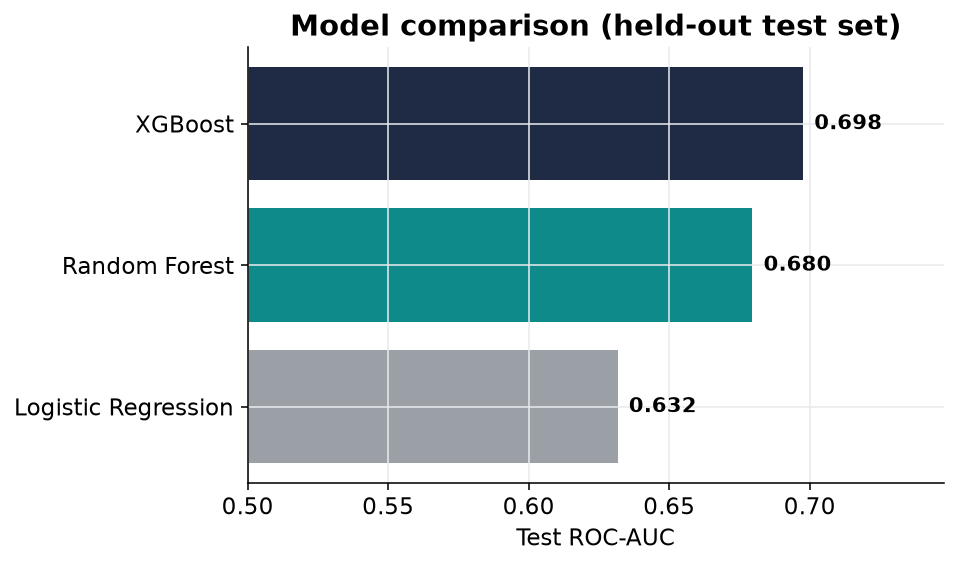

In [5]:
comp = pd.DataFrame(results["model_comparison"]).T
display(comp.round(4))
display(Image(filename=str(C.FIG_DIR / "model_comparison.png")))

In [6]:
print("Best tuned params:", results["tuning"]["best_params"])
print(f"Best CV AUC: {results['tuning']['best_cv_auc']:.4f}")
print(f"5-fold CV AUC: {results['cv']['mean_auc']:.4f} ± {results['cv']['std_auc']:.4f}")

Best tuned params: {'subsample': 0.7, 'reg_lambda': 2.0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 0.9}
Best CV AUC: 0.6970
5-fold CV AUC: 0.6986 ± 0.0032


## 4. Calibration & the base-rate correction

A churn *score* is not a churn *probability* unless it's calibrated. We apply
isotonic calibration and check the reliability curve and Brier score. We then
convert calibrated probabilities from the oversampled sample back to the true
population base rate — without this, every downstream dollar figure is inflated.

Brier (raw):        0.2196
Brier (calibrated): 0.2194  (lower = better)
AUC (calibrated):   0.6986

Mean P(churn) in sample:      0.497
Mean P(churn) re-weighted:    0.027  (target ~0.02)


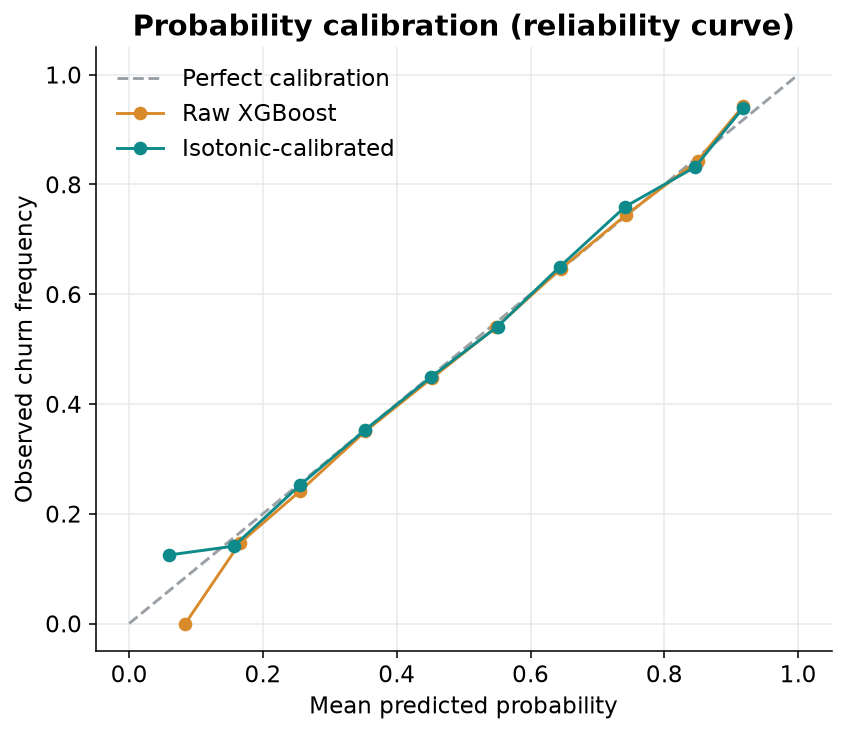

In [7]:
cal = results["calibration"]
print(f"Brier (raw):        {cal['brier_raw']:.4f}")
print(f"Brier (calibrated): {cal['brier_calibrated']:.4f}  (lower = better)")
print(f"AUC (calibrated):   {cal['auc_calibrated']:.4f}")

br = results["base_rate"]
print(f"\nMean P(churn) in sample:      {br['mean_p_sample']:.3f}")
print(f"Mean P(churn) re-weighted:    {br['mean_p_true']:.3f}  (target ~{br['true_rate']})")
display(Image(filename=str(C.FIG_DIR / "calibration.png")))

## 5. Who to call first — capture curve

Ranking customers by **expected value at risk (EVaR = P(churn) × margin × CLV)**
lets retention reach far more churners per call than random outreach.

Contacting the top 20% by EVaR captures 27% of churners
Lift vs random: 1.34x


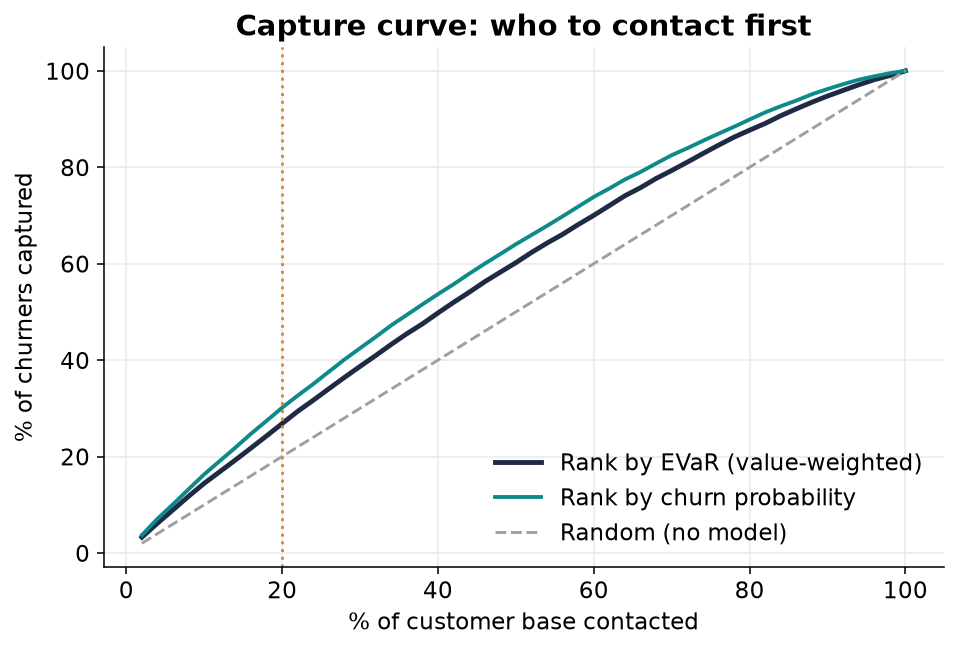

In [8]:
cap = results["capture_at_20pct"]
print(f"Contacting the top 20% by EVaR captures {cap['by_evar']*100:.0f}% of churners")
print(f"Lift vs random: {cap['lift_evar_vs_random']:.2f}x")
display(Image(filename=str(C.FIG_DIR / "capture_curve.png")))

## 6. How many to call — profit curve

We don't pick a threshold by intuition. We sweep contact depth and choose the
point that **maximizes expected net profit** given the offer cost, save rate, and
recovered CLV (base scenario).

Optimal contact depth: 42% of base
Net profit (population): $189,190
ROI: 2.39x
Expected customers saved: 351


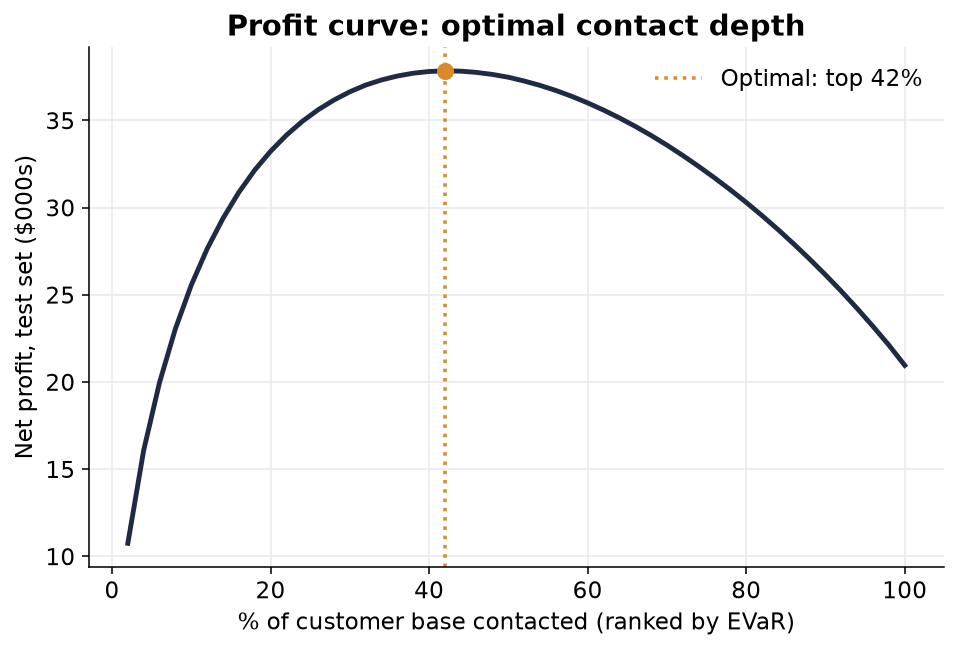

In [9]:
pc = results["profit_curve_base"]
print(f"Optimal contact depth: {pc['optimal_frac']*100:.0f}% of base")
print(f"Net profit (population): ${pc['optimal_net_profit_population']:,.0f}")
print(f"ROI: {pc['optimal_roi']:.2f}x")
print(f"Expected customers saved: {pc['customers_saved_population']:,.0f}")
display(Image(filename=str(C.FIG_DIR / "profit_curve.png")))

## 7. Why — SHAP drivers

SHAP gives directionally honest, per-feature contributions. Equipment age, usage
trend, and care-call intensity dominate — all **actionable** levers (upgrade offers,
win-back on declining usage, service recovery), unlike demographics.

,mean|SHAP|
eqpdays,0.2350
months,0.1640
mou_trend,0.1392
mou_3m_vs_life,0.1330
totmrc_Mean,0.0877
hnd_price,0.0740
avgqty,0.0675
change_mou,0.0603
asl_flag_N,0.0463
rev_trend,0.0456


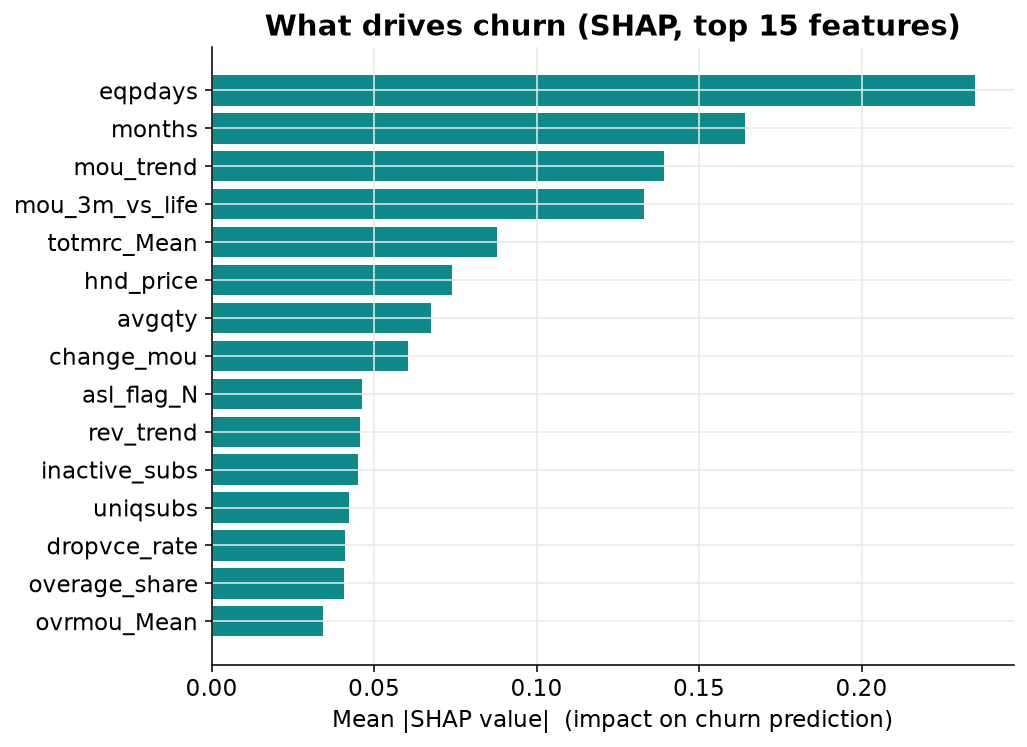

In [10]:
shap_imp = pd.Series(results["shap_top_features"]).sort_values(ascending=False)
display(shap_imp.round(4).to_frame("mean|SHAP|"))
display(Image(filename=str(C.FIG_DIR / "shap_importance.png")))

## 8. Honest handset/equipment view

Equipment age is binned into interpretable buckets (rather than implying false
precision). Churn rises monotonically with handset age — a clean upgrade-offer story.

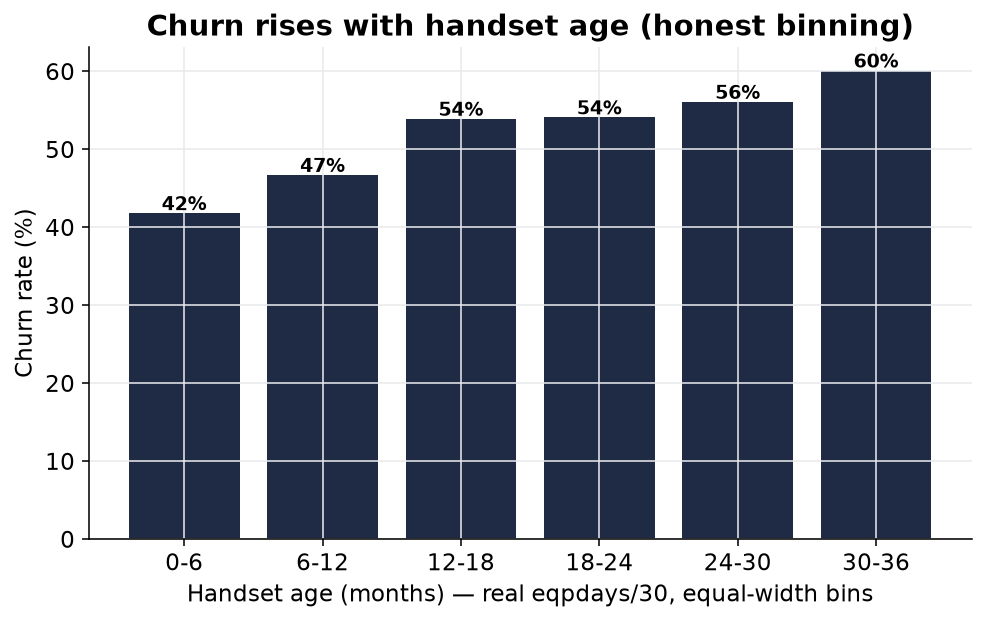

In [11]:
display(Image(filename=str(C.FIG_DIR / "handset_churn.png")))

## 9. Persuadables — uplift modeling

**Important honesty note:** this dataset is *observational* — there is no
treatment/control split, so true causal uplift cannot be measured here. We
demonstrate the persuadables framework with a **clearly-labeled simulated**
campaign response and a T-learner, and we recommend a live A/B holdout to measure
real uplift before scaling.

T-learner (two-model), SIMULATED treatment response
Observational data has no treatment/control; response is simulated under documented assumptions to demonstrate the persuadables framework. A live A/B holdout is recommended.

Mean uplift, top-20% persuadables: 0.356
Share with positive uplift:        95%


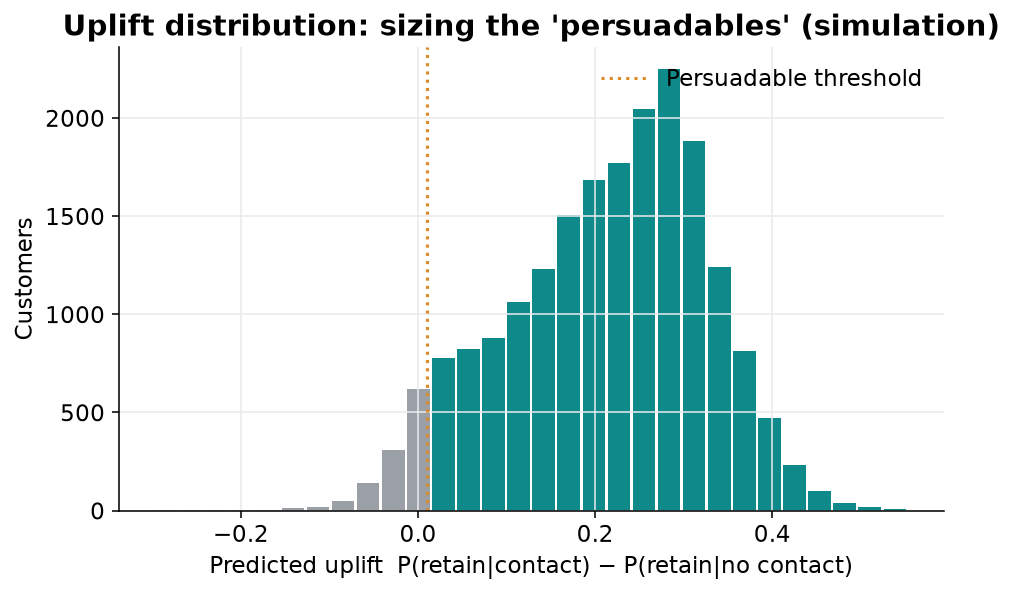

In [12]:
up = results["uplift"]
print(up["method"])
print(up["note"])
print(f"\nMean uplift, top-20% persuadables: {up['mean_uplift_top20']:.3f}")
print(f"Share with positive uplift:        {up['persuadable_share_positive_uplift']*100:.0f}%")
display(Image(filename=str(C.FIG_DIR / "uplift.png")))

## 10. Customer personas — K-means

Real K-means on standardized behavioral features (not demographics) yields
actionable segments, each profiled by churn rate, revenue, equipment age, and
care intensity.

,cluster,size,share,churn_rate,avg_rev,avg_eqp_months,avg_care
0,0,10348,0.517,0.471,49.523,9.559,0.004
1,1,167,0.008,0.838,43.675,15.219,0.146
2,2,5285,0.264,0.515,46.745,22.667,0.003
3,3,4200,0.210,0.518,95.242,9.643,0.003


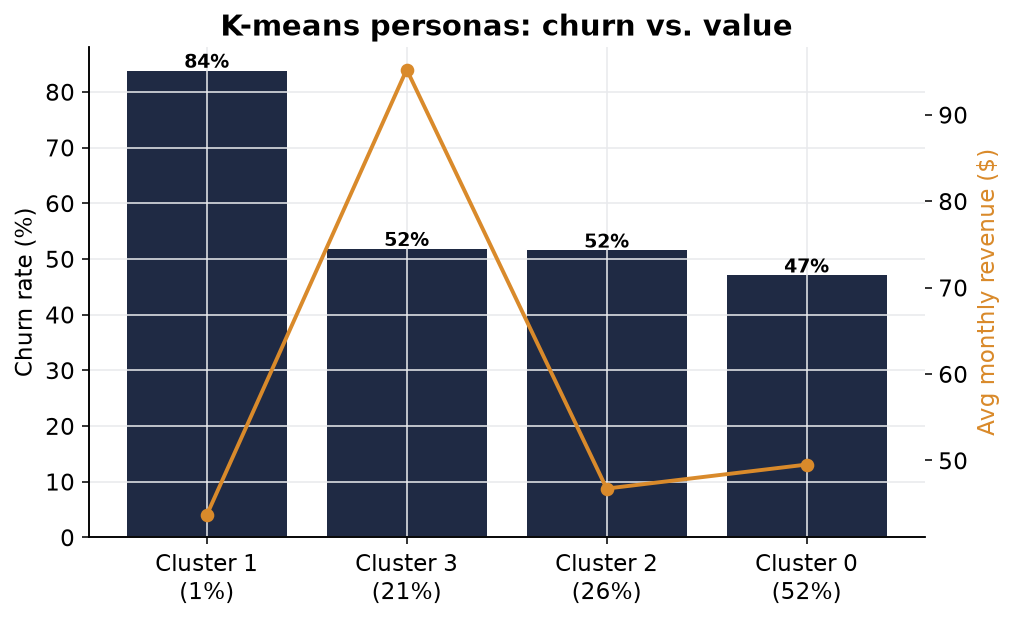

In [13]:
personas = pd.DataFrame(results["personas"]["clusters"])
display(personas.round(3))
display(Image(filename=str(C.FIG_DIR / "personas.png")))

## 11. Business case — bear / base / bull

A single optimistic number is not credible. We present three scenarios with
assumptions cited in `REFERENCES.md` (save rate, offer cost, gross margin, CLV
horizon). Even the **bear** case is profit-positive.

,name,save_rate,offer_cost,net_profit_population,roi,customers_saved_population
0,Bear,0.12,35,-36379.37,0.79,210.67
1,Base,0.20,30,189190.10,2.39,351.12
2,Bull,0.28,25,493383.04,6.12,491.57


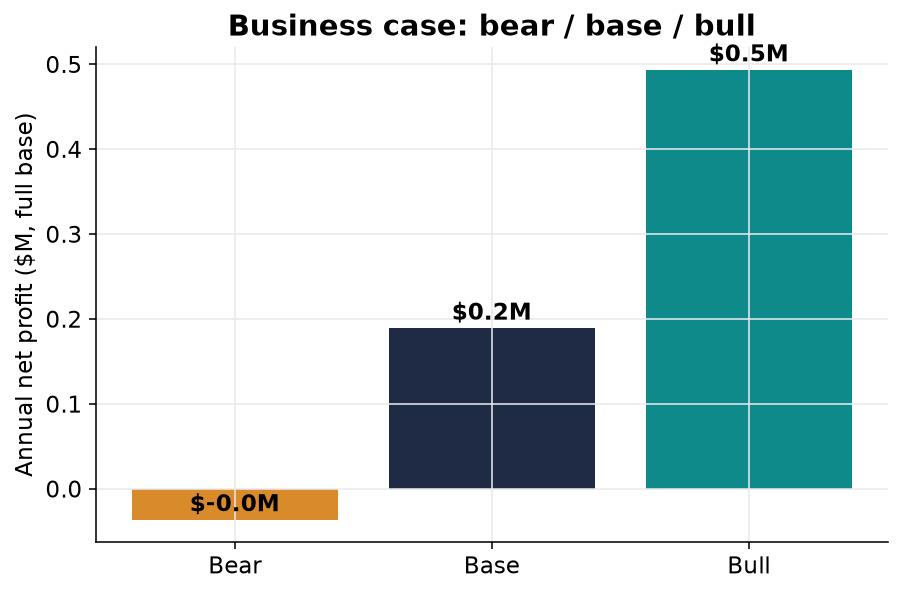

In [14]:
scen = pd.DataFrame(results["scenarios"])
cols = ["name", "save_rate", "offer_cost", "net_profit_population",
        "roi", "customers_saved_population"]
display(scen[[c for c in cols if c in scen.columns]].round(2))
display(Image(filename=str(C.FIG_DIR / "scenarios.png")))

## 12. Takeaways

- **Model:** tuned, calibrated XGBoost; realistic AUC (~0.70), good Brier score.
- **Targeting:** rank by EVaR, contact at the profit-optimal depth.
- **Drivers:** equipment age, usage decline, care intensity — all actionable.
- **Economics:** profit-positive across bear/base/bull; clear ROI.
- **Integrity:** no protected attributes; honest base rate; uplift flagged as a
  simulation pending a real RCT.

All figures and `results.json` in `outputs/` were produced by the cells above.